# 04 — Period Detection

This notebook estimates the dominant pulsation period of the Vela pulsar using preprocessed photon arrival times.

## Objectives

- load the preprocessed photon event dataset;
- perform an epoch-folding period search;
- identify the strongest candidate period;
- visualize the period search result;
- save the period detection plot.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

processed_path = PROJECT_ROOT / "data" / "processed" / "vela_photons_filtered.csv"
images_dir = PROJECT_ROOT / "notebooks" / "images"

images_dir.mkdir(parents=True, exist_ok=True)

processed_path

WindowsPath('C:/Users/vi/pulsar-clean/data/processed/vela_photons_filtered.csv')

In [3]:
df_filtered = pd.read_csv(processed_path)

df_filtered.head()

,time,energy,time_rel
0,7.805337e+08,326.514008,79221.431558
1,7.805415e+08,207.780685,87021.198388
2,7.805529e+08,229.124054,98457.021602
3,7.805640e+08,271.309235,109584.648355
4,7.806201e+08,207.057602,165607.811719


In [4]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 405068 entries, 0 to 405067
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   time      405068 non-null  float64
 1   energy    405068 non-null  float64
 2   time_rel  405068 non-null  float64
dtypes: float64(3)
memory usage: 9.3 MB


## Epoch-folding period search

For each trial period, photon arrival times are folded into phase bins. A chi-square statistic is calculated to estimate how strongly the folded profile differs from a uniform distribution.

A stronger deviation from uniformity indicates a more likely pulsation period.

In [5]:
def epoch_folding_chi_square(times, period, n_bins=32):
    phases = (times % period) / period
    counts, _ = np.histogram(phases, bins=n_bins, range=(0, 1))

    expected = counts.mean()

    if expected == 0:
        return np.nan

    chi_square = np.sum((counts - expected) ** 2 / expected)
    return chi_square

In [6]:
times = df_filtered["time_rel"].values

trial_periods = np.linspace(0.085, 0.095, 1000)

chi_square_values = np.array([
    epoch_folding_chi_square(times, period, n_bins=32)
    for period in trial_periods
])

best_period = trial_periods[np.nanargmax(chi_square_values)]

best_period

np.float64(0.08942442442442443)

In [7]:
print(f"Best period: {best_period:.6f} seconds")
print(f"Best frequency: {1 / best_period:.3f} Hz")

Best period: 0.089424 seconds
Best frequency: 11.183 Hz


## Period search result

The peak in the chi-square curve corresponds to the strongest candidate pulsation period found in the selected search range.

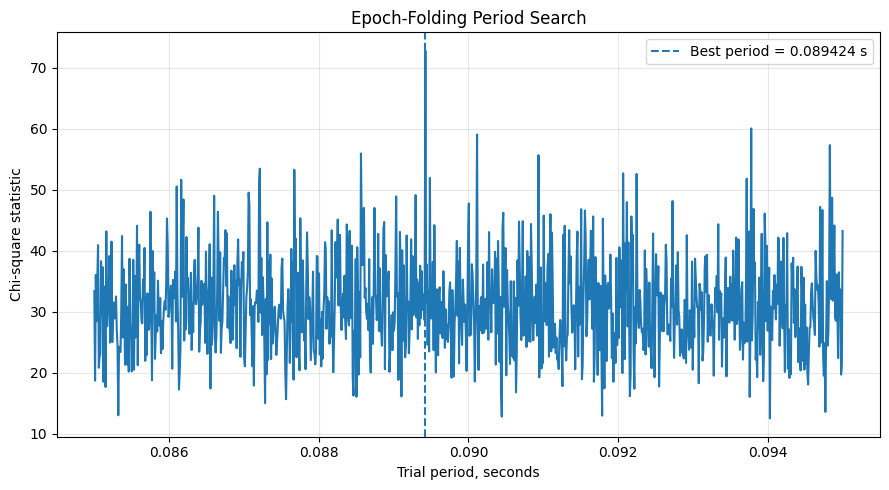

WindowsPath('C:/Users/vi/pulsar-clean/notebooks/images/04_period_detection.png')

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(trial_periods, chi_square_values)
plt.axvline(best_period, linestyle="--", label=f"Best period = {best_period:.6f} s")
plt.xlabel("Trial period, seconds")
plt.ylabel("Chi-square statistic")
plt.title("Epoch-Folding Period Search")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = images_dir / "04_period_detection.png"
plt.savefig(plot_path, dpi=150)

plt.show()

plot_path

## Summary

The epoch-folding search identifies the strongest candidate period within the selected range. The detected period is close to the expected Vela pulsar rotation period, which supports the validity of the photon timing workflow.

This simplified approach is suitable for an educational data analysis project. A production-level pulsar timing pipeline would require more rigorous corrections, barycentric timing, uncertainty estimation, and validation against observational metadata.